# Loading & Looking at the Data

This is data that simulates real-world reactors in different conditions and different fault-modes. (Read more in the source on Kaggle: https://www.kaggle.com/datasets/rohit8527kmr7518/chemical-process-monitoring-time-series-dataset)

This data enables me to:
- differentiate between baseline and stressed condition
- for different reactors (e.g. cross-validation possible)
- in a time-series with simulated influence of the weather (temperature)
- to form a ML-model to:
    - classify the fault
    - forecast how much time is left before the fault occurs -> predictive maintenance
        - and which metric is most to be looked at
    - forecast the production efficiency degradation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('archive/chemical_process_timeseries.csv')

In [3]:
data.head()

,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,91.927424,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,NaN
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,NaN,302.283603,0.728999,...,91.581466,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,NaN
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,91.895056,82.006626,1.448190,NaN,NaN,NaN,12.0,0,NaN,NaN
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,91.544885,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,NaN
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,NaN,99.302349,78.571707,304.811418,0.732308,...,92.258005,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,NaN,NaN


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 777600 entries, 0 to 777599
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             777600 non-null  str    
 1   operating_regime      777600 non-null  str    
 2   reactor_id            777600 non-null  str    
 3   ambient_temp_effect   731039 non-null  float64
 4   reactor_temp          730635 non-null  float64
 5   reactor_pressure      730457 non-null  float64
 6   feed_flow_rate        730840 non-null  float64
 7   coolant_flow_rate     730955 non-null  float64
 8   agitator_speed_rpm    730825 non-null  float64
 9   reaction_rate         730770 non-null  float64
 10  conversion_rate       731184 non-null  float64
 11  selectivity           730391 non-null  float64
 12  yield_pct             731076 non-null  float64
 13  vibration_rms         731141 non-null  float64
 14  motor_current         730983 non-null  float64
 15  power_consu

In [5]:
data['operating_regime'].value_counts()

operating_regime
A    388800
B    388800
Name: count, dtype: int64

In [6]:
data['reactor_id'].value_counts()

reactor_id
A_R1    129600
A_R2    129600
A_R3    129600
B_R1    129600
B_R2    129600
B_R3    129600
Name: count, dtype: int64

In [7]:
data['fault_type'].value_counts()

fault_type
0    749699
1      9143
4      7442
2      6842
3      4474
Name: count, dtype: int64

<Axes: xlabel='time_to_fault_min', ylabel='Count'>

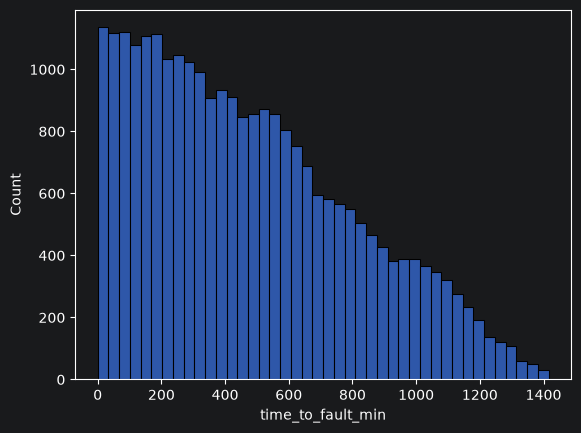

In [8]:
sns.histplot(data['time_to_fault_min'])

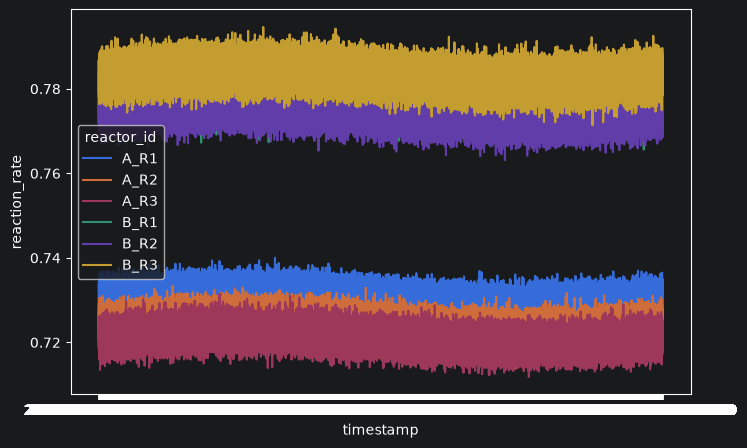

In [15]:
#takes a very long amount of time, because of the sheer amount of data
'''plt.figure(figsize=(8,5))
sns.lineplot(data= data, x='timestamp',y='reaction_rate', hue='reactor_id')
plt.show()'''

In [16]:
data['timestamp'].sort_values()

0         2024-01-01 00:00:00
129600    2024-01-01 00:00:00
259200    2024-01-01 00:00:00
388800    2024-01-01 00:00:00
518400    2024-01-01 00:00:00
                 ...         
518399    2024-03-30 23:59:00
259199    2024-03-30 23:59:00
129599    2024-03-30 23:59:00
647999    2024-03-30 23:59:00
777599    2024-03-30 23:59:00
Name: timestamp, Length: 777600, dtype: str

data is "gathered" for three months

In [5]:
data['time_to_fault_min'].sort_values(ascending=False)

46152     1416.0
46153     1415.0
46154     1414.0
46155     1413.0
46156     1412.0
           ...  
777595       NaN
777596       NaN
777597       NaN
777598       NaN
777599       NaN
Name: time_to_fault_min, Length: 777600, dtype: float64

this column has a lot of NaNs.. thinking about how they are structured or measured (e.g. only the entries before a fault are given, but for how long before?)

In [9]:
data[data['fault_type']!= 0]['fault_type'].count()

np.int64(27901)

time_to_fault_min     26287 non-null   float64

there are more faults than times to fault -> I have to fill only some of them (where there is a fault, but no time)

<Axes: xlabel='fault_type', ylabel='Count'>

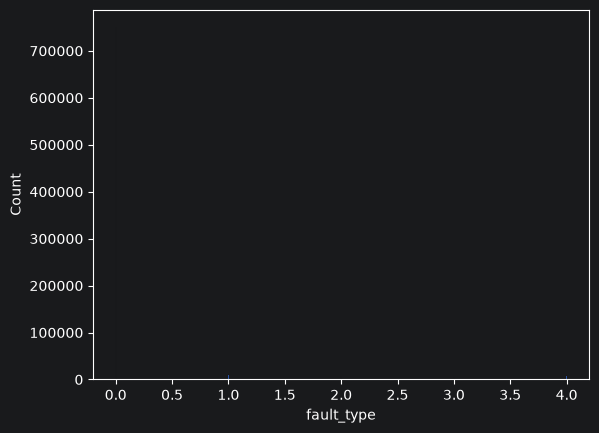

In [7]:
sns.histplot(data, x='fault_type')